# 1 Importing and Merging Dataset

In [106]:
import pandas as pd
from fitparse import FitFile
from collections import Counter
from pathlib import Path
from datetime import datetime, timedelta

In [107]:
from fitparse import FitFile

fitfile = FitFile("../data/444053264780_WELLNESS.fit")

for i, msg in enumerate(fitfile.get_messages("stress_level")):
    print(msg.get_values())

    if i == 5:
        break

{'stress_level_time': datetime.datetime(2026, 5, 31, 8, 36), 'stress_level_value': 22, 'unknown_2': 11, 'unknown_3': 74, 'unknown_4': 1}
{'stress_level_time': datetime.datetime(2026, 5, 31, 8, 37), 'stress_level_value': 36, 'unknown_2': -15, 'unknown_3': 74, 'unknown_4': 1}
{'stress_level_time': datetime.datetime(2026, 5, 31, 8, 38), 'stress_level_value': 34, 'unknown_2': -12, 'unknown_3': 74, 'unknown_4': 1}
{'stress_level_time': datetime.datetime(2026, 5, 31, 8, 39), 'stress_level_value': 42, 'unknown_2': -22, 'unknown_3': 74, 'unknown_4': 1}
{'stress_level_time': datetime.datetime(2026, 5, 31, 8, 40), 'stress_level_value': 33, 'unknown_2': -10, 'unknown_3': 74, 'unknown_4': 1}
{'stress_level_time': datetime.datetime(2026, 5, 31, 8, 41), 'stress_level_value': 36, 'unknown_2': -15, 'unknown_3': 74, 'unknown_4': 1}


### Stress

In [108]:
rows = []

for msg in fitfile.get_messages("stress_level"):
    row = msg.get_values()
    rows.append({
        "timestamp": row["stress_level_time"],
        "stress": row["stress_level_value"]
    })

stress_df = pd.DataFrame(rows)
stress_df["stress"] = stress_df["stress"].replace([-1, -2], pd.NA)

stress_df.head()

,timestamp,stress
0,2026-05-31 08:36:00,22
1,2026-05-31 08:37:00,36
2,2026-05-31 08:38:00,34
3,2026-05-31 08:39:00,42
4,2026-05-31 08:40:00,33


In [109]:
stress_df.tail()

,timestamp,stress
610,2026-05-31 19:04:00,36
611,2026-05-31 19:05:00,33
612,2026-05-31 19:06:00,30
613,2026-05-31 19:07:00,42
614,2026-05-31 19:08:00,49


### Heart Rate

In [110]:
rows = []

current_date = None

for msg in fitfile.get_messages("monitoring"):
    row = msg.get_values()

    # Update current date whenever Garmin provides a full timestamp
    if "timestamp" in row:
        current_date = row["timestamp"].date()

    # Heart-rate records
    if "heart_rate" in row and "timestamp_16" in row and current_date is not None:

        seconds = row["timestamp_16"]

        timestamp = datetime.combine(
            current_date,
            datetime.min.time()
        ) + timedelta(seconds=seconds)

        rows.append({
            "timestamp": timestamp,
            "heart_rate": row["heart_rate"]
        })

heart_rate_df = pd.DataFrame(rows)

heart_rate_df.head()

,timestamp,heart_rate
0,2026-05-31 11:51:16,67
1,2026-05-31 11:52:16,69
2,2026-05-31 11:53:16,70
3,2026-05-31 11:54:16,73
4,2026-05-31 11:55:16,74


In [111]:
heart_rate_df.tail()

,timestamp,heart_rate
556,2026-05-31 04:08:00,77
557,2026-05-31 04:09:00,73
558,2026-05-31 04:10:00,72
559,2026-05-31 04:11:00,73
560,2026-05-31 04:12:00,75


### Body Battery

In [112]:
rows = []

for msg in fitfile.get_messages("stress_level"):
    row = msg.get_values()

    rows.append({
        "timestamp": row["stress_level_time"],
        "body_battery": row["unknown_3"]
    })

body_battery_df = pd.DataFrame(rows)
body_battery_df["body_battery"] = body_battery_df["body_battery"].replace([-1, -2], pd.NA)

body_battery_df.head()

,timestamp,body_battery
0,2026-05-31 08:36:00,74
1,2026-05-31 08:37:00,74
2,2026-05-31 08:38:00,74
3,2026-05-31 08:39:00,74
4,2026-05-31 08:40:00,74


In [113]:
body_battery_df.tail()

,timestamp,body_battery
610,2026-05-31 19:04:00,22
611,2026-05-31 19:05:00,22
612,2026-05-31 19:06:00,22
613,2026-05-31 19:07:00,22
614,2026-05-31 19:08:00,21


### Respirational Rate

In [114]:
GARMIN_EPOCH = datetime(1989, 12, 31)

rows = []

for msg in fitfile.get_messages("unknown_297"):
    row = msg.get_values()

    rows.append({
        "timestamp": GARMIN_EPOCH + timedelta(seconds=row["unknown_253"]),
        "respiration_rate": row["unknown_0"] / 100
    })

respiration_df = pd.DataFrame(rows)

# Garmin missing values
respiration_df.loc[
    respiration_df["respiration_rate"] < 0,
    "respiration_rate"
] = pd.NA

respiration_df.head()

,timestamp,respiration_rate
0,2026-05-31 08:35:00,17.66
1,2026-05-31 08:36:00,18.25
2,2026-05-31 08:37:00,17.58
3,2026-05-31 08:38:00,19.16
4,2026-05-31 08:39:00,18.08


In [115]:
respiration_df.tail()

,timestamp,respiration_rate
629,2026-05-31 19:04:00,17.00
630,2026-05-31 19:05:00,16.41
631,2026-05-31 19:06:00,15.08
632,2026-05-31 19:07:00,18.25
633,2026-05-31 19:08:00,19.16


### Merging

In [116]:
# Make sure timestamps are datetime
for df in [stress_df, body_battery_df, respiration_df, heart_rate_df]:
    df["timestamp"] = pd.to_datetime(df["timestamp"])

# Pick the day from the data
day = stress_df["timestamp"].dt.normalize().iloc[0]

# Full 1-minute timeline: 00:00 to 23:59
full_index = pd.date_range(
    start=day,
    end=day + pd.Timedelta(days=1) - pd.Timedelta(minutes=1),
    freq="1min"
)

def prepare_minute_df(df, value_col):
    temp = df.copy()
    
    # Round/floor timestamps down to minute
    temp["timestamp"] = temp["timestamp"].dt.floor("min")
    
    # If duplicate values exist in the same minute, average them
    temp = (
        temp.groupby("timestamp", as_index=True)[value_col]
        .mean()
        .to_frame()
    )
    
    return temp

stress_min = prepare_minute_df(stress_df, "stress")
body_battery_min = prepare_minute_df(body_battery_df, "body_battery")
respiration_min = prepare_minute_df(respiration_df, "respiration_rate")
heart_rate_min = prepare_minute_df(heart_rate_df, "heart_rate")

# Combine into one standardized dataframe
daily_df = pd.DataFrame(index=full_index)

daily_df = daily_df.join(stress_min)
daily_df = daily_df.join(body_battery_min)
daily_df = daily_df.join(respiration_min)
daily_df = daily_df.join(heart_rate_min)

daily_df.index.name = "timestamp"

# Optional: reset index if you want timestamp as a normal column
daily_df = daily_df.reset_index()

daily_df

,timestamp,stress,body_battery,respiration_rate,heart_rate
0,2026-05-31 00:00:00,NaN,NaN,NaN,NaN
1,2026-05-31 00:01:00,NaN,NaN,NaN,84.0
2,2026-05-31 00:02:00,NaN,NaN,NaN,90.0
3,2026-05-31 00:03:00,NaN,NaN,NaN,95.0
4,2026-05-31 00:04:00,NaN,NaN,NaN,92.0
...,...,...,...,...,...
1435,2026-05-31 23:55:00,NaN,NaN,NaN,NaN
1436,2026-05-31 23:56:00,NaN,NaN,NaN,NaN
1437,2026-05-31 23:57:00,NaN,NaN,NaN,NaN
1438,2026-05-31 23:58:00,NaN,NaN,NaN,NaN


In [117]:
print("Shape:")
print(daily_df.shape)

print("\nColumns:")
print(daily_df.columns.tolist())

print("\nData Types:")
print(daily_df.dtypes)

daily_df.head()


Shape:
(1440, 5)

Columns:
['timestamp', 'stress', 'body_battery', 'respiration_rate', 'heart_rate']

Data Types:
timestamp           datetime64[us]
stress                      object
body_battery               float64
respiration_rate           float64
heart_rate                 float64
dtype: object


,timestamp,stress,body_battery,respiration_rate,heart_rate
0,2026-05-31 00:00:00,NaN,NaN,NaN,NaN
1,2026-05-31 00:01:00,NaN,NaN,NaN,84.0
2,2026-05-31 00:02:00,NaN,NaN,NaN,90.0
3,2026-05-31 00:03:00,NaN,NaN,NaN,95.0
4,2026-05-31 00:04:00,NaN,NaN,NaN,92.0


# 2 EDA

### Missing Values

In [118]:
daily_df.isna().sum()
daily_df.describe()
daily_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1440 entries, 0 to 1439
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   timestamp         1440 non-null   datetime64[us]
 1   stress            472 non-null    object        
 2   body_battery      615 non-null    float64       
 3   respiration_rate  488 non-null    float64       
 4   heart_rate        561 non-null    float64       
dtypes: datetime64[us](1), float64(3), object(1)
memory usage: 56.4+ KB


In [119]:
daily_df["stress"].value_counts(dropna=False)

stress
NaN     968
54.0     19
66.0     18
72.0     16
69.0     15
       ... 
92.0      1
24.0      1
35.0      1
88.0      1
38.0      1
Name: count, Length: 70, dtype: int64

In [120]:
daily_df["timestamp"].min()
daily_df["timestamp"].max()

Timestamp('2026-05-31 23:59:00')

In [121]:
daily_df["stress"].value_counts()

stress
54.0    19
66.0    18
72.0    16
69.0    15
75.0    14
        ..
92.0     1
24.0     1
35.0     1
88.0     1
38.0     1
Name: count, Length: 69, dtype: int64

In [122]:
from pathlib import Path

folder = Path(r"C:\Vrije University\Vrije University\VU\P6\Machine Learning for the Quantified Self\ML4QS\final_dfs")

files = list(folder.glob("*.csv"))

print("Number of files:", len(files))

for f in files:
    print(f.name)

from pathlib import Path

files = list(Path("final_dfs").glob("*.csv"))

print(files)
print(len(files))

Number of files: 2
2026-06-03.csv
2026-06-04.csv
[]
0


In [123]:
import pandas as pd
from pathlib import Path

folder = Path(r"C:\Vrije University\Vrije University\VU\P6\Machine Learning for the Quantified Self\ML4QS\final_dfs")

dfs = []

for file in folder.glob("*.csv"):
    print("Loading:", file)
    dfs.append(pd.read_csv(file))

print("Loaded files:", len(dfs))

Loading: C:\Vrije University\Vrije University\VU\P6\Machine Learning for the Quantified Self\ML4QS\final_dfs\2026-06-03.csv
Loading: C:\Vrije University\Vrije University\VU\P6\Machine Learning for the Quantified Self\ML4QS\final_dfs\2026-06-04.csv
Loaded files: 2


In [124]:
all_df = pd.concat(dfs, ignore_index=True)

print(all_df.shape)
corr = all_df.corr(numeric_only=True)
print(corr)

(2880, 10)
                    stress  body_battery  respiration_rate  heart_rate  \
stress            1.000000     -0.050002         -0.023885    0.108275   
body_battery     -0.050002      1.000000         -0.079695   -0.079729   
respiration_rate -0.023885     -0.079695          1.000000   -0.002904   
heart_rate        0.108275     -0.079729         -0.002904    1.000000   
intensity         0.195886      0.286027          0.170457   -0.116811   
cycles           -0.014748      0.181579          0.192490   -0.243765   
active_time      -0.026837      0.171302          0.201297   -0.252885   
active_calories  -0.024560      0.165803          0.200704   -0.242878   

                  intensity    cycles  active_time  active_calories  
stress             0.195886 -0.014748    -0.026837        -0.024560  
body_battery       0.286027  0.181579     0.171302         0.165803  
respiration_rate   0.170457  0.192490     0.201297         0.200704  
heart_rate        -0.116811 -0.243765    -

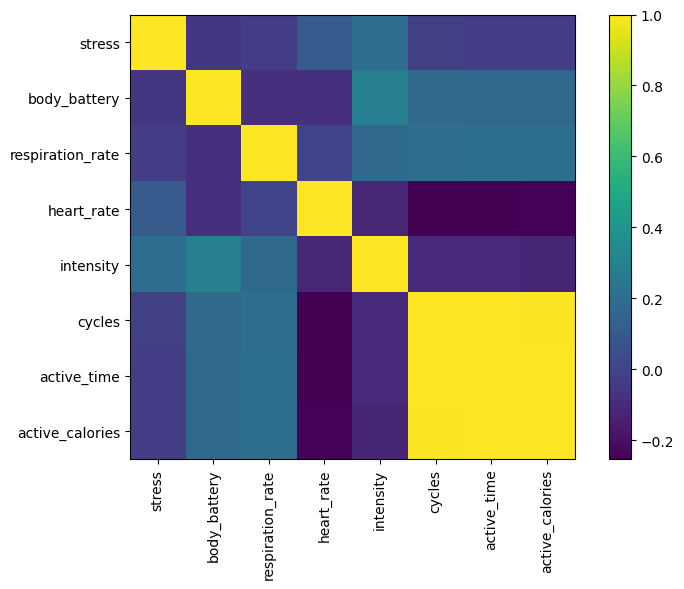

In [125]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.imshow(corr)
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.tight_layout()
plt.show()

In [126]:
print(all_df.shape)
print(all_df.info())

(2880, 10)
<class 'pandas.DataFrame'>
RangeIndex: 2880 entries, 0 to 2879
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   timestamp         2880 non-null   str    
 1   stress            2515 non-null   float64
 2   body_battery      2746 non-null   float64
 3   respiration_rate  2300 non-null   float64
 4   heart_rate        1892 non-null   float64
 5   activity_type     151 non-null    str    
 6   intensity         151 non-null    float64
 7   cycles            151 non-null    float64
 8   active_time       151 non-null    float64
 9   active_calories   151 non-null    float64
dtypes: float64(8), str(2)
memory usage: 225.1 KB
None


In [127]:
all_df.isnull().sum()

timestamp              0
stress               365
body_battery         134
respiration_rate     580
heart_rate           988
activity_type       2729
intensity           2729
cycles              2729
active_time         2729
active_calories     2729
dtype: int64

In [128]:
all_df.describe()

,stress,body_battery,respiration_rate,heart_rate,intensity,cycles,active_time,active_calories
count,2515.000000,2746.000000,2300.000000,1892.000000,151.000000,151.000000,151.000000,151.000000
mean,23.233797,54.357975,14.473139,70.485729,2.940397,3332.470199,3745.728477,225.417219
std,23.015236,21.274416,2.495619,14.521790,1.822935,2773.915602,2987.587481,176.766866
min,-2.000000,21.000000,0.000000,44.000000,0.000000,0.000000,4.000000,0.000000
25%,7.000000,37.000000,12.910000,59.000000,2.000000,298.250000,612.500000,37.500000
50%,17.000000,51.000000,14.720000,68.000000,2.000000,3108.000000,3628.000000,228.000000
75%,34.000000,72.000000,16.000000,79.000000,4.000000,5624.000000,6215.000000,374.000000
max,98.000000,95.000000,21.750000,135.000000,7.000000,8623.000000,8866.000000,495.000000


<Axes: >

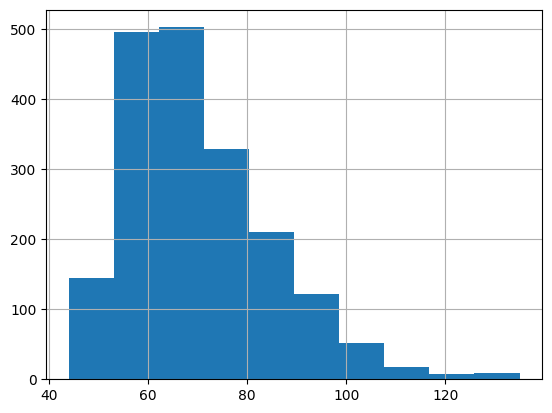

In [129]:
all_df["heart_rate"].hist()

<Axes: >

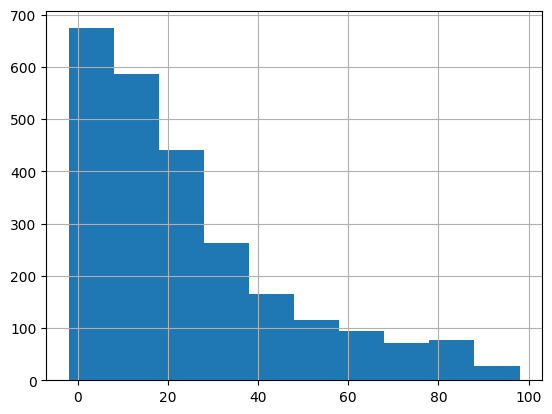

In [130]:
all_df["stress"].hist()